Loading dataset and processing data in MPa...


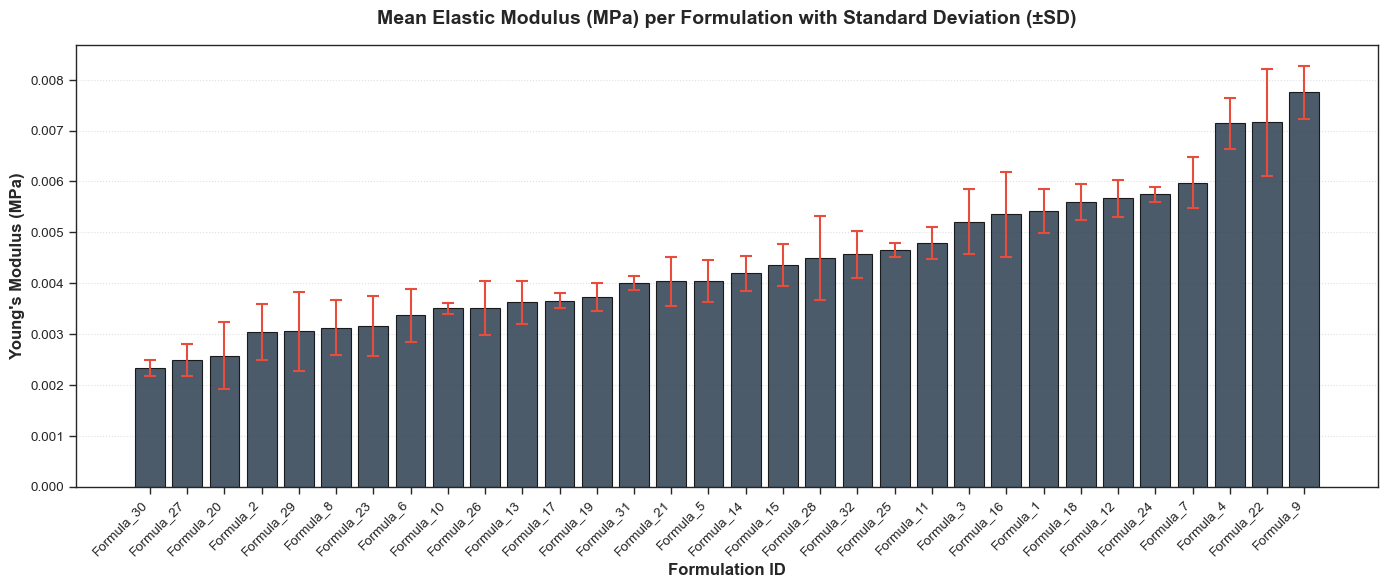

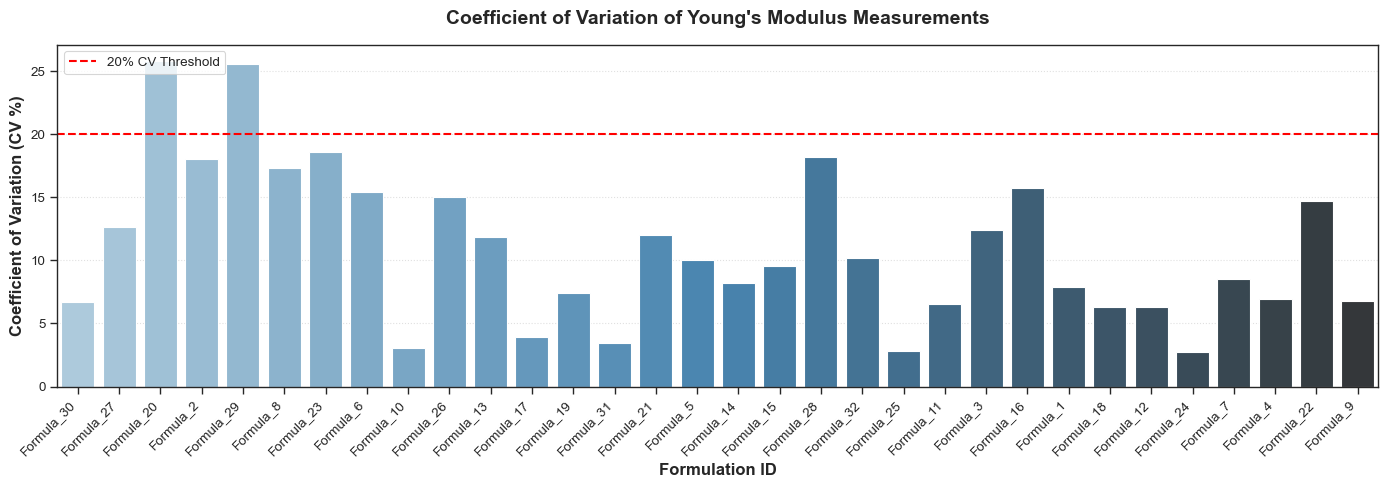


FORMULATION STATISTICAL SUMMARY (MPa):


,Formula_ID,HEMA_mean,PEGDA_mean,LAP_mean,Sample_Count,Young Modulus (MPa) [Mean ± SD],CV (%)
0,Formula_30,41.70,20.41,0.479,3,0.002 ± 0.000,6.733309
1,Formula_27,40.92,20.85,0.055,3,0.002 ± 0.000,12.674009
2,Formula_20,48.79,19.66,0.498,3,0.003 ± 0.001,25.794040
3,Formula_2,43.49,18.73,0.360,3,0.003 ± 0.001,18.007334
4,Formula_29,40.37,20.23,0.265,3,0.003 ± 0.001,25.568927
5,Formula_8,43.99,18.01,0.136,3,0.003 ± 0.001,17.291436
6,Formula_23,42.04,21.13,0.471,3,0.003 ± 0.001,18.572618
7,Formula_6,42.54,19.40,0.119,3,0.003 ± 0.001,15.389595
8,Formula_10,47.11,19.28,0.406,3,0.004 ± 0.000,3.089040
9,Formula_26,51.52,20.57,0.069,3,0.004 ± 0.001,15.036148


In [2]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

print("Loading dataset and processing data in MPa...")

# Target dataset path
target_file = 'HPLW_23july_results.csv' # or 'HPLW_23july_results.xlsx'

# Column names configuration
col_young_pa = 'E_Pa'
col_err_rel = 'Relative Error %'
col_formula = 'Formula_ID'

# 1. Load data
if target_file.endswith('.csv'):
    df_raw = pd.read_csv(target_file)
else:
    df_raw = pd.read_excel(target_file)

# Clean column name spaces
df_raw.columns = df_raw.columns.str.strip()

# Automatically detect Elastic Modulus column name if needed
if col_young_pa not in df_raw.columns:
    for col in ['E(pa)', 'E_pa', 'E (pa)']:
        if col in df_raw.columns:
            col_young_pa = col
            break

# 2. Data Cleaning and Unit Conversion (Pa to MPa)
df_raw['Temp_Value'] = df_raw[col_young_pa].astype(str).str.strip().str.upper()
df_initial = df_raw[~df_raw['Temp_Value'].isin(['NO DATA', 'NG', 'ERROR', 'NAN', 'NONE', 'NULL', ''])].copy()
df_initial = df_initial.drop(columns=['Temp_Value'])

# Convert to numerical values
df_initial[col_young_pa] = pd.to_numeric(df_initial[col_young_pa], errors='coerce')
df_initial[col_err_rel] = pd.to_numeric(df_initial[col_err_rel], errors='coerce')

# Drop rows with NaN values in target columns
df_measurable = df_initial.dropna(subset=[col_young_pa, col_err_rel]).copy()

# Add new column in MPa (Pa / 1e6)
df_measurable['Young Modulus (MPa)'] = df_measurable[col_young_pa] / 1e6

# =====================================================================
# FILTERING BY INSTRUMENTAL RELATIVE ERROR
# =====================================================================
def filter_by_relative_error(group, error_threshold=3.0):
    valid_mask = group[col_err_rel] <= error_threshold
    return group[valid_mask]

# Apply filter grouped by formulation
df_super_clean = (
    df_measurable
    .groupby([col_formula], group_keys=False)
    .apply(filter_by_relative_error)
)


# =====================================================================
# STATISTICAL SUMMARY (Mean, SD, CV %)
# =====================================================================
summary_df = df_super_clean.groupby([col_formula]).agg(
    HEMA_mean=('HEMA (%)', 'mean'),
    PEGDA_mean=('PEGDA (%)', 'mean'),
    LAP_mean=('LAP (%)', 'mean'),
    Sample_Count=('Young Modulus (MPa)', 'count'),
    Mean_MPa=('Young Modulus (MPa)', 'mean'),
    SD_MPa=('Young Modulus (MPa)', 'std')
).reset_index()

# Calculate Coefficient of Variation (CV %) = (SD / Mean) * 100
summary_df['CV (%)'] = (summary_df['SD_MPa'] / summary_df['Mean_MPa']) * 100

# Publication format (Mean ± SD)
summary_df['Young Modulus (MPa) [Mean ± SD]'] = (
    summary_df['Mean_MPa'].map('{:.3f}'.format) + " ± " + summary_df['SD_MPa'].map('{:.3f}'.format)
)

# Sort formulations by mean modulus
summary_df = summary_df.sort_values(by='Mean_MPa', ascending=True).reset_index(drop=True)

# =====================================================================
# PLOTTING RESULTS (Publication-Ready Figures)
# =====================================================================
sns.set_theme(style="ticks", context="paper", font_scale=1.1)

# --- Figure 1: Mean Young's Modulus (MPa) with Error Bars (±SD) ---
fig, ax1 = plt.subplots(figsize=(14, 6))

x_indices = np.arange(len(summary_df))
bars = ax1.bar(
    x_indices, 
    summary_df['Mean_MPa'], 
    yerr=summary_df['SD_MPa'], 
    capsize=4, 
    color='#2C3E50', 
    edgecolor='black', 
    alpha=0.85,
    error_kw=dict(ecolor='#E74C3C', lw=1.5, capthick=1.5)
)

ax1.set_ylabel("Young's Modulus (MPa)", fontweight='bold', fontsize=12)
ax1.set_xlabel("Formulation ID", fontweight='bold', fontsize=12)
ax1.set_title("Mean Elastic Modulus (MPa) per Formulation with Standard Deviation (±SD)", fontweight='bold', fontsize=14, pad=15)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(summary_df[col_formula], rotation=45, ha='right')
ax1.yaxis.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("Youngs_Modulus_MPa_Summary.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 2: Reproducibility Analysis (CV %) ---
fig, ax2 = plt.subplots(figsize=(14, 5))

sns.barplot(
    x=col_formula, 
    y='CV (%)', 
    data=summary_df, 
    ax=ax2, 
    palette='Blues_d'
)

# Add threshold line for high reproducibility (< 5% or 10%)
ax2.axhline(20, color='red', linestyle='--', linewidth=1.5, label='20% CV Threshold')

ax2.set_ylabel("Coefficient of Variation (CV %)", fontweight='bold', fontsize=12)
ax2.set_xlabel("Formulation ID", fontweight='bold', fontsize=12)
ax2.set_title("Coefficient of Variation of Young's Modulus Measurements", fontweight='bold', fontsize=14, pad=15)
ax2.set_xticklabels(summary_df[col_formula], rotation=45, ha='right')
ax2.yaxis.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig("Formulation_CV_Analysis.png", dpi=300, bbox_inches='tight')
plt.savefig("Formulation_CV_Analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()

# =====================================================================
# DISPLAY SUMMARY TABLE
# =====================================================================
print("\nFORMULATION STATISTICAL SUMMARY (MPa):")
summary_df[['Formula_ID', 'HEMA_mean', 'PEGDA_mean', 'LAP_mean', 'Sample_Count', 'Young Modulus (MPa) [Mean ± SD]', 'CV (%)']]

Generating unified reproducibility analysis in a single plot...


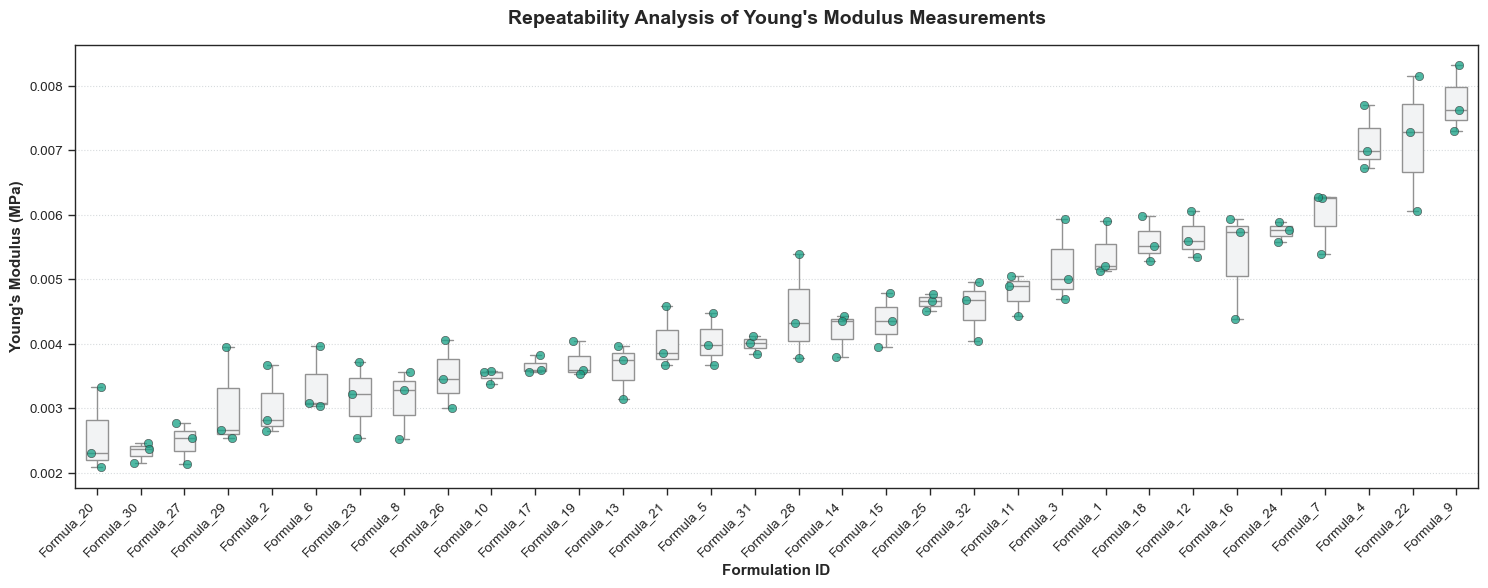

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("Generating unified reproducibility analysis in a single plot...")

# Ensure Elastic Modulus is converted to MPa
col_young = 'Young Modulus (MPa)'

if col_young not in df_super_clean.columns:
    if 'Young Modulus (Kpa)' in df_super_clean.columns:
        df_super_clean[col_young] = df_super_clean['Young Modulus (Kpa)'] / 1000.0
    elif 'Young Modulus (kPa)' in df_super_clean.columns:
        df_super_clean[col_young] = df_super_clean['Young Modulus (kPa)'] / 1000.0
    elif 'E_Pa' in df_super_clean.columns:
        df_super_clean[col_young] = df_super_clean['E_Pa'] / 1e6

# Make a copy to avoid modifying original dataframe
df_plot = df_super_clean.copy()

# Sort formulations by median Young's Modulus in ascending order
formula_order = (
    df_plot.groupby("Formula_ID")[col_young]
    .median()
    .sort_values()
    .index
)

# Configure plot style
sns.set_theme(style="ticks", context="paper", font_scale=1.1)

fig, ax = plt.subplots(figsize=(15, 6))

# 1. Boxplot (Distribution summary)
sns.boxplot(
    x="Formula_ID",
    y=col_young,
    data=df_plot,
    order=formula_order,
    color="#F2F3F4",
    width=0.5,
    showfliers=False,
    ax=ax,
)

# 2. Stripplot (Individual data points overlay)
sns.stripplot(
    x="Formula_ID",
    y=col_young,
    data=df_plot,
    order=formula_order,
    size=6,
    color="#16A085",
    alpha=0.75,
    jitter=0.2,
    linewidth=0.5,
    ax=ax,
)

# Axis labels and main title
ax.set_title(
    "Repeatability Analysis of Young's Modulus Measurements",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_ylabel("Young's Modulus (MPa)", fontweight="bold", fontsize=11)
ax.set_xlabel("Formulation ID", fontweight="bold", fontsize=11)

# Rotate X-axis labels for optimal readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Add horizontal gridlines
ax.yaxis.grid(True, linestyle=":", alpha=0.6, color="#BDC3C7")

plt.tight_layout()

# Save high-resolution figure (300 DPI) for publication
plt.savefig("Repeatability_Analysis_Young's Modulus.png", dpi=300, bbox_inches="tight")
plt.savefig("Repeatability_Analysis_Young's Modulus.pdf", dpi=300, bbox_inches="tight")
plt.show()

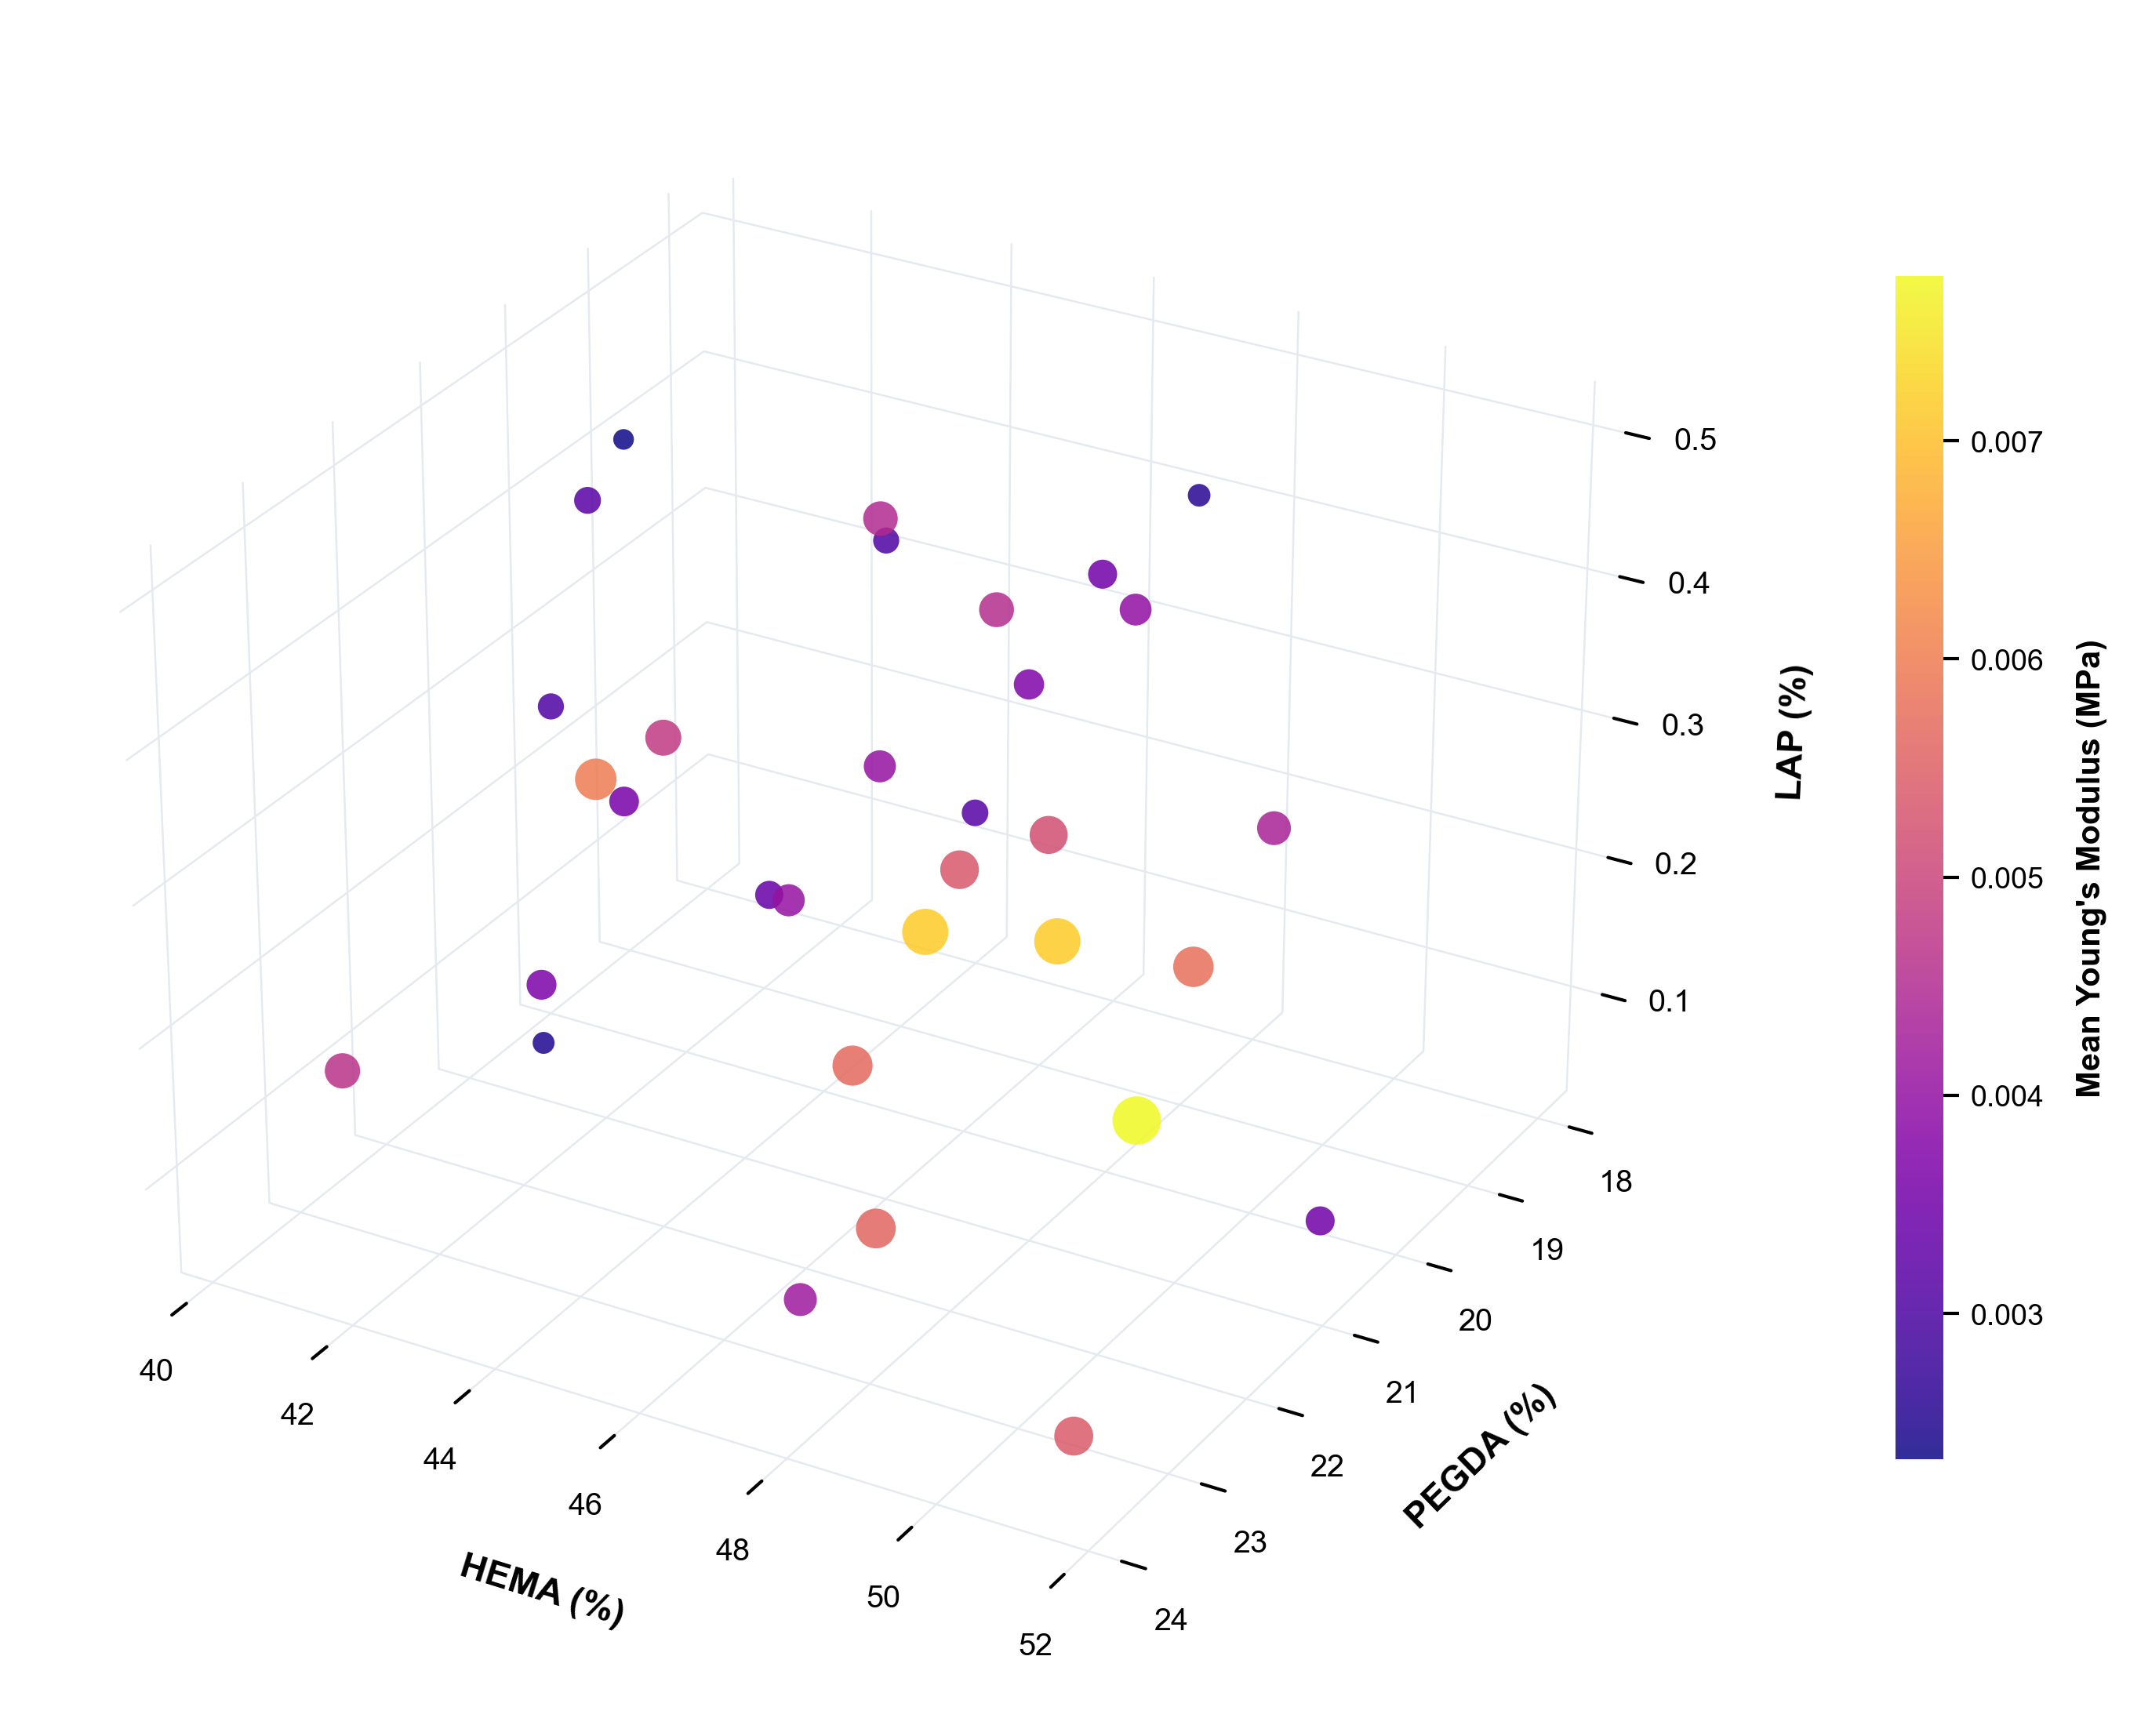

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Preparation
df_plot = df_super_clean.copy()
target_col = "Young Modulus (MPa)"

if target_col not in df_plot.columns:
    if "Young Modulus (kPa)" in df_plot.columns:
        df_plot[target_col] = df_plot["Young Modulus (kPa)"] / 1000.0
    elif "Young Modulus (Kpa)" in df_plot.columns:
        df_plot[target_col] = df_plot["Young Modulus (Kpa)"] / 1000.0
    elif "E_Pa" in df_plot.columns:
        df_plot[target_col] = df_plot["E_Pa"] / 1e6
    else:
        raise KeyError("No Young's modulus column found.")

required_cols = ["Formula_ID", "HEMA (%)", "PEGDA (%)", "LAP (%)", target_col]
df_mean = (
    df_plot.dropna(subset=required_cols)
    .groupby("Formula_ID", as_index=False)
    .agg(
        {
            "HEMA (%)": "mean",
            "PEGDA (%)": "mean",
            "LAP (%)": "mean",
            target_col: "mean",
        }
    )
)

# Marker sizing based on value range
mod_min = df_mean[target_col].min()
mod_max = df_mean[target_col].max()
sizes = 40 + 180 * (df_mean[target_col] - mod_min) / (mod_max - mod_min)

# 2. High-Resolution Plot Setup
fig = plt.figure(figsize=(10, 7.5), dpi=300)
ax = fig.add_subplot(111, projection="3d")

# Plotting with the 'plasma' colormap and no harsh black borders
scatter = ax.scatter(
    df_mean["HEMA (%)"],
    df_mean["PEGDA (%)"],
    df_mean["LAP (%)"],
    c=df_mean[target_col],
    s=sizes,
    cmap="plasma",
    edgecolors="none",
    alpha=0.85,
)

# 3. Clean Background & Muted Gridlines
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

grid_style = {"color": "#E5E9F0", "linewidth": 0.6, "linestyle": "-"}
ax.xaxis._axinfo["grid"].update(grid_style)
ax.yaxis._axinfo["grid"].update(grid_style)
ax.zaxis._axinfo["grid"].update(grid_style)

# Hide rigid outer box outlines safely
ax.xaxis.line.set_color((1, 1, 1, 0))
ax.yaxis.line.set_color((1, 1, 1, 0))
ax.zaxis.line.set_color((1, 1, 1, 0))

# 4. Bold, Solid Black Typography & Labels
ax.set_xlabel("HEMA (%)", fontsize=11, color="#000000", fontweight="bold", labelpad=12)
ax.set_ylabel("PEGDA (%)", fontsize=11, color="#000000", fontweight="bold", labelpad=12)
ax.set_zlabel("LAP (%)", fontsize=11, color="#000000", fontweight="bold", labelpad=12)

# CHANGED: Invert the PEGDA axis to mirror the exact layout of the target image
ax.invert_yaxis()

# Set the 3D perspective camera angle
ax.view_init(elev=28, azim=-60)

# Solid black ticks with slightly larger font size
ax.tick_params(axis="both", labelsize=9.5, colors="#000000")

# 5. Sleek Colorbar Layout with Bold Black Text
cbar = fig.colorbar(scatter, ax=ax, shrink=0.7, pad=0.08, aspect=25)
cbar.set_label(
    "Mean Young's Modulus (MPa)", fontsize=10, color="#000000", fontweight="bold", labelpad=10
)
cbar.ax.tick_params(labelsize=9, colors="#000000")
cbar.outline.set_visible(False)

plt.tight_layout()

# 6. Save as High-Quality PNG
plt.savefig("LHS_3D_Formulation_Space.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.savefig("LHS_3D_Young_Modulus.pdf", dpi=400, bbox_inches="tight", facecolor="white")

plt.show()

Total replicate-level data points evaluated: 96
   HEMA (%)  PEGDA (%)  LAP (%)  Young's Modulus (MPa)
0     43.12      22.66    0.216               0.003824
1     47.25      23.17    0.080               0.004435
2     47.11      19.28    0.406               0.003382
3     46.69      18.43    0.339               0.003852
4     43.49      18.73    0.360               0.003671


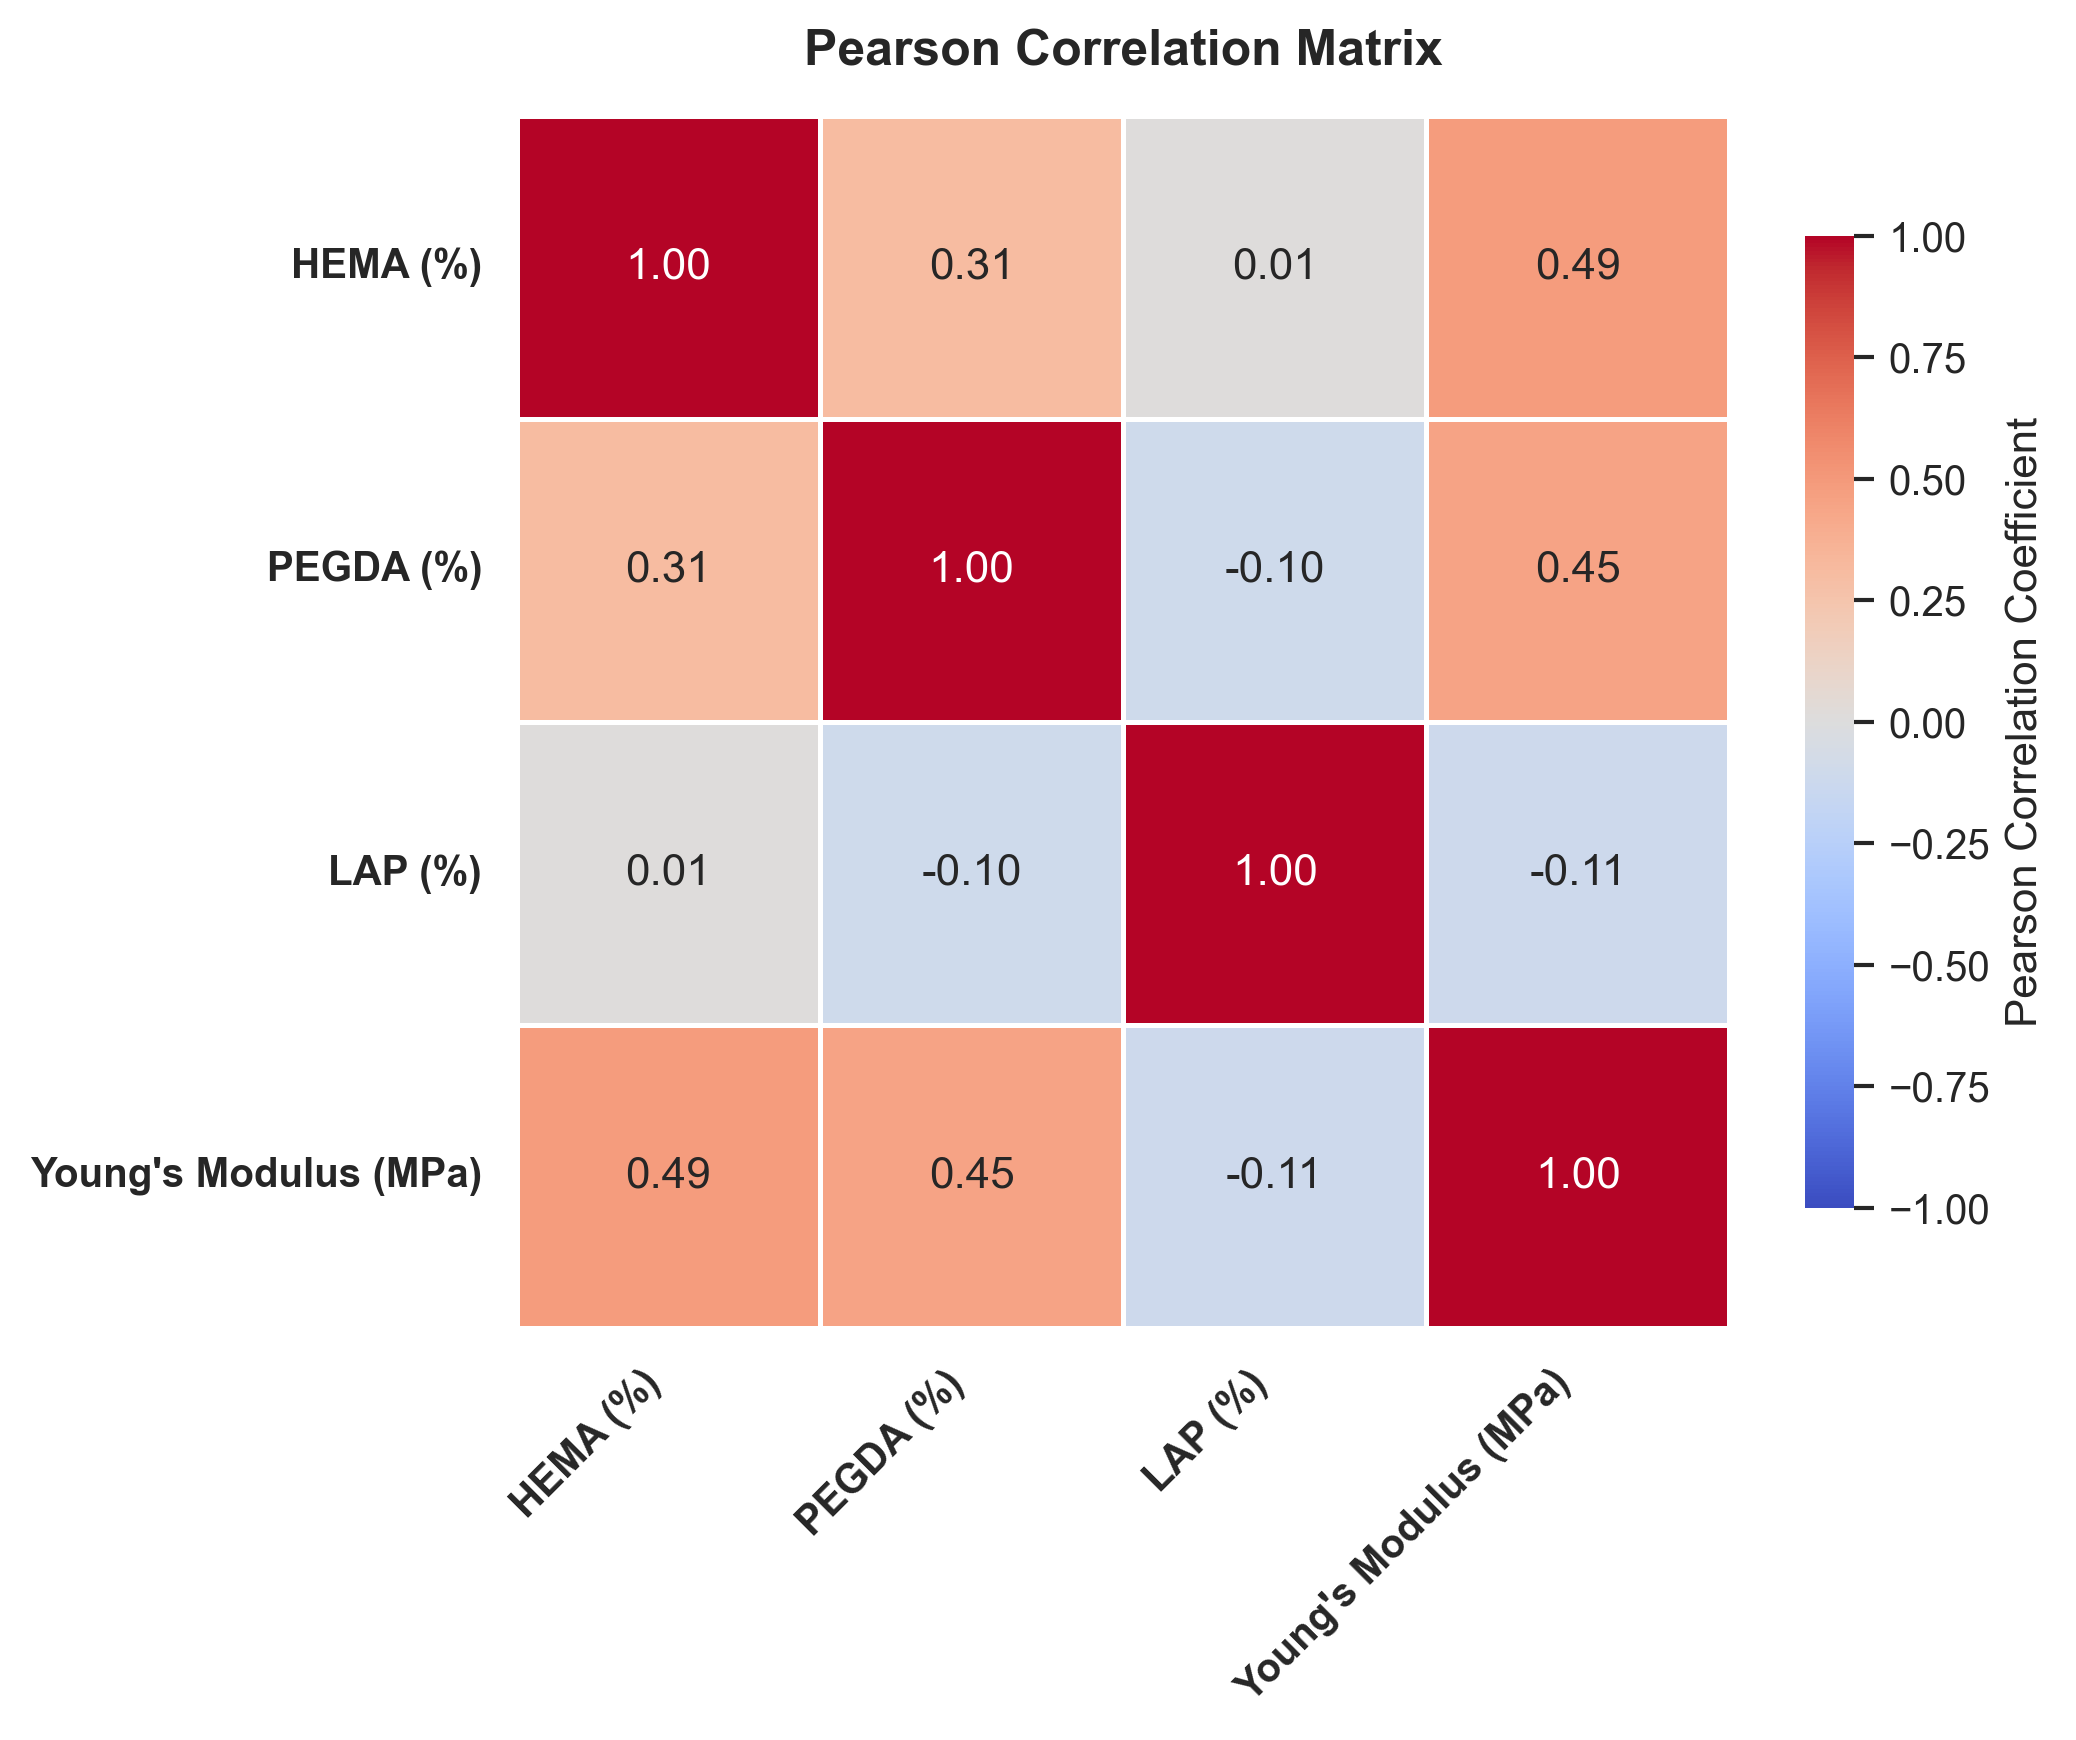

In [6]:
"""
Pearson Correlation Matrix for Young's Modulus based on full replicate dataset.
Water content and formulation-level averaging are removed per reviewer request.
"""

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =========================================================
# 0. General style
# =========================================================
sns.set_theme(style="white", context="paper", font_scale=1.1)
plt.rcParams["font.family"] = "sans-serif"

# =========================================================
# 1. Prepare data
# =========================================================
df = df_super_clean.copy()

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Target column: Young's modulus in MPa
target_col = "Young's Modulus (MPa)"

if target_col not in df.columns:
    if "Young Modulus (MPa)" in df.columns:
        df[target_col] = df["Young Modulus (MPa)"]
    elif "Young Modulus (kPa)" in df.columns:
        df[target_col] = df["Young Modulus (kPa)"] / 1000.0
    elif "E_Pa" in df.columns:
        df[target_col] = df["E_Pa"] / 1e6
    else:
        raise ValueError(
            "No Young's modulus column found. Expected 'Young Modulus (MPa)', "
            "'Young Modulus (kPa)', or 'E_Pa'."
        )

# Independent features ONLY (Water is intentionally excluded)
features_corr = ["HEMA (%)", "PEGDA (%)", "LAP (%)"]

# Filter out rows with missing values in target or independent features
df_corr_full = df.dropna(subset=features_corr + [target_col])

print(f"Total replicate-level data points evaluated: {len(df_corr_full)}")
print(df_corr_full[features_corr + [target_col]].head())

# =========================================================
# 2. Pearson correlation matrix based on ALL REPLICATES
# =========================================================
corr_df = df_corr_full[features_corr + [target_col]]
corr_matrix = corr_df.corr(method="pearson")

plt.figure(figsize=(7.0, 5.8), dpi=300)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    center=0,
    square=True,
    linewidths=0.8,
    cbar_kws={
        "shrink": 0.8,
        "label": "Pearson Correlation Coefficient"
    },
)

plt.title(
    "Pearson Correlation Matrix",
    fontweight="bold",
    fontsize=12,
    pad=12,
)

plt.xticks(rotation=45, ha="right", fontweight="bold")
plt.yticks(rotation=0, fontweight="bold")
plt.tight_layout()

# Save the updated matrix figures
plt.savefig("young_modulus_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.savefig("young_modulus_correlation_matrix.pdf", bbox_inches="tight")
plt.show()